# Positive experiments
the actual class ratio is changed of the actual positive class in the dataset is now the changing variable, label frequency remains a constant ±20%

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_experiment import load_experiment_results 
import datetime 
from helpers import get_n_labels


In [2]:
EXPERIMENT = "positive_ratio"

In [3]:
df = load_experiment_results(name=EXPERIMENT)
df = df[df["model"]!="oracle"]
df.columns

Index(['positive_ratio', 'dataset', 'iter', 'model', 'accuracy', '0 precision',
       '1 precision', '0 recall', '1 recall', '0 f1', '1 f1', '0 support',
       '1 support', 'calculated_c', 'feature'],
      dtype='object')

In [4]:
df["precision"] = (df["0 precision"]+df["1 precision"]) / 2
df["recall"] = (df["0 recall"]+df["1 recall"]) / 2
df["f1"] = (df["0 f1"]+df["1 f1"]) / 2

df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(4)
df[["precision","recall","f1"]].describe()

,precision,recall,f1
count,600.000000,600.000000,600.000000
mean,0.590416,0.610061,0.521950
std,0.258559,0.132955,0.207575
min,0.048400,0.467600,0.088200
25%,0.352100,0.500000,0.375500
50%,0.650000,0.522200,0.477300
75%,0.824050,0.709575,0.697000
max,1.000000,1.000000,1.000000


In [5]:
fig_experiment_folder = EXPERIMENT
os.makedirs(fig_experiment_folder, exist_ok=True)
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
fig_folder = os.path.join(fig_experiment_folder, f"{current_time}")
os.makedirs(fig_folder, exist_ok=True)

In [6]:
df["calculated_c"].unique()

array([0.])

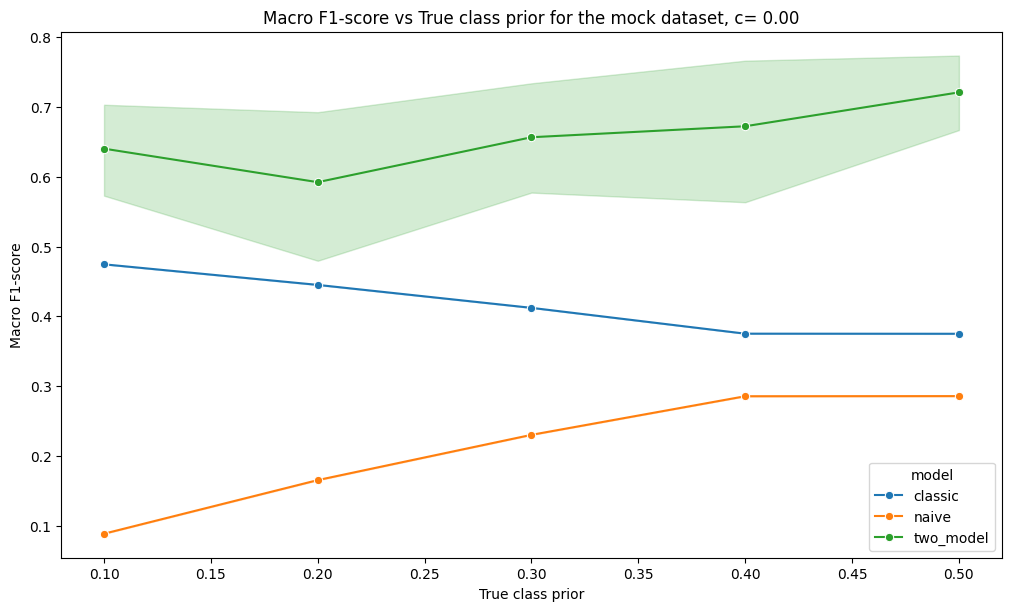

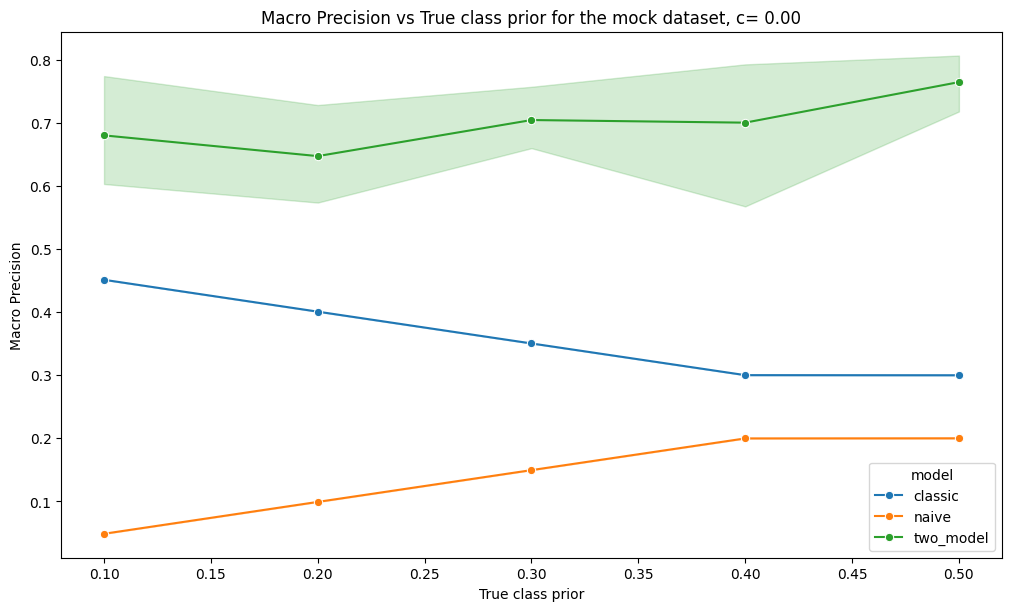

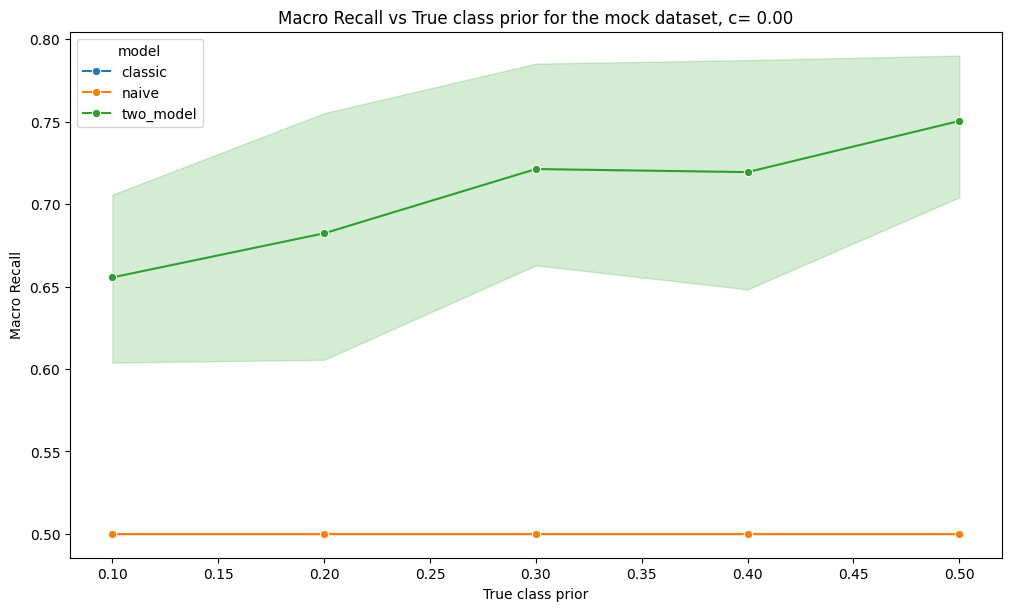

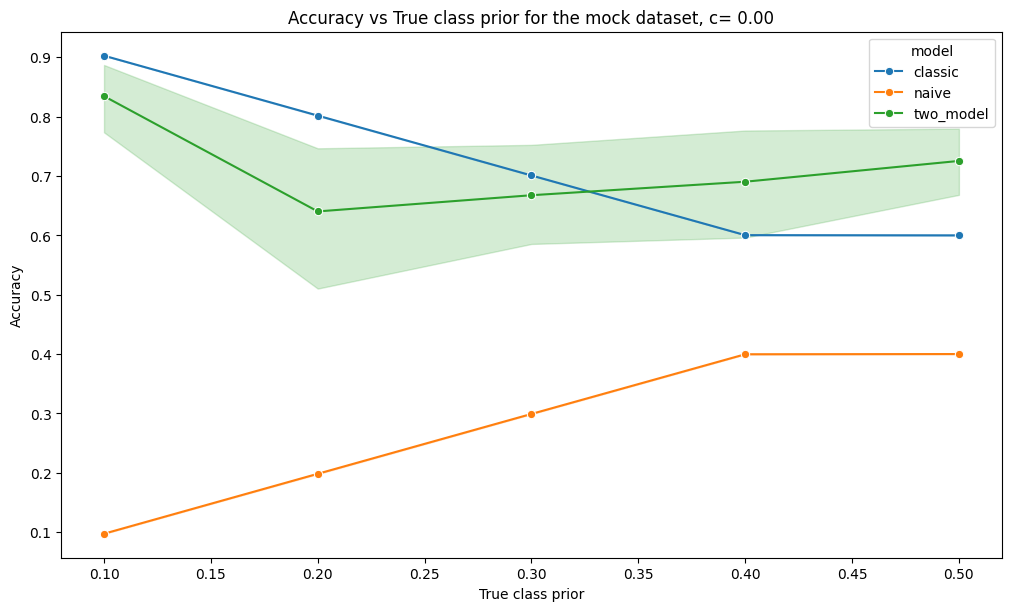

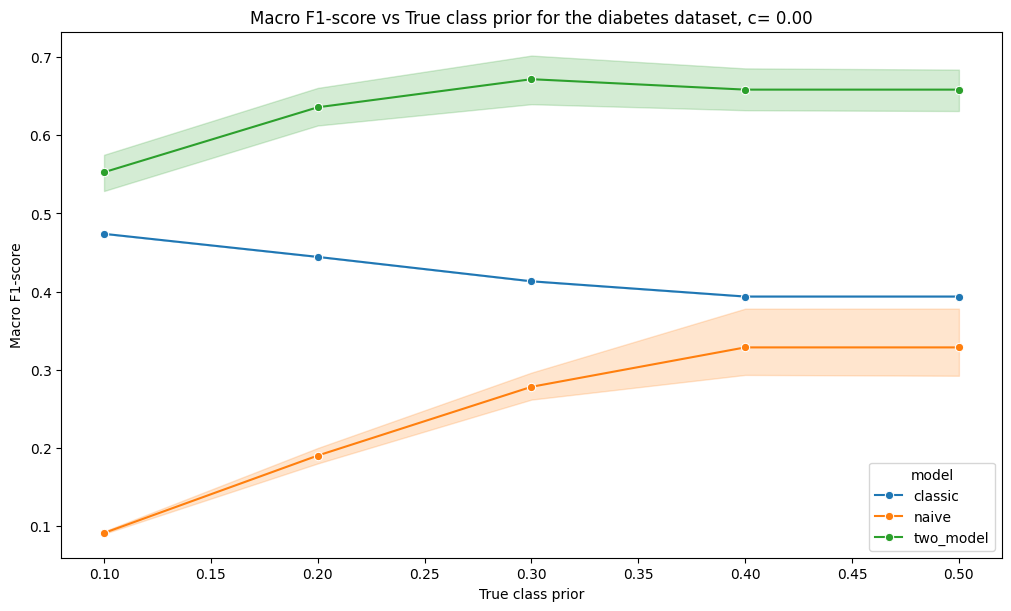

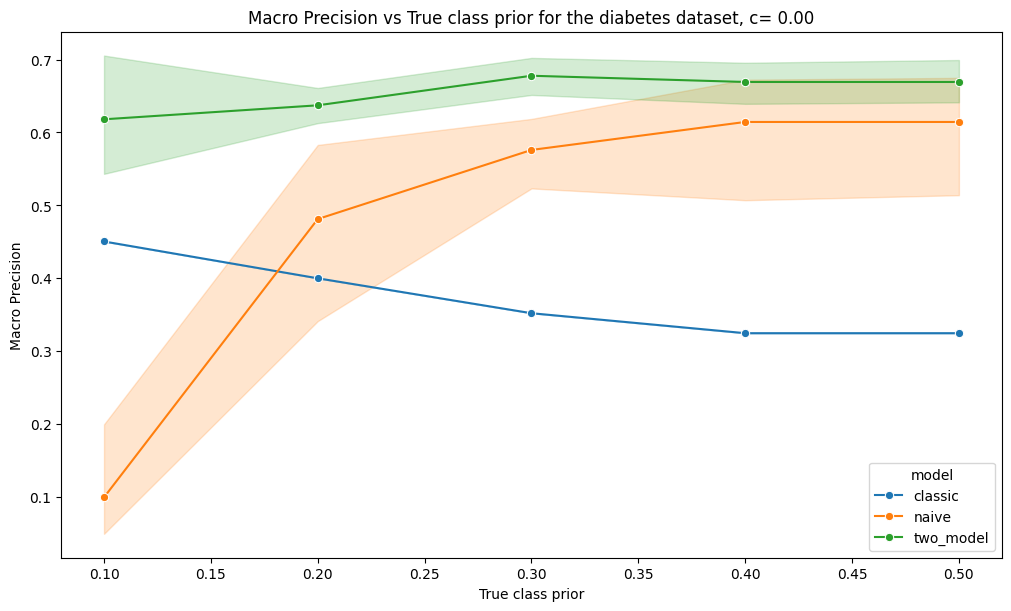

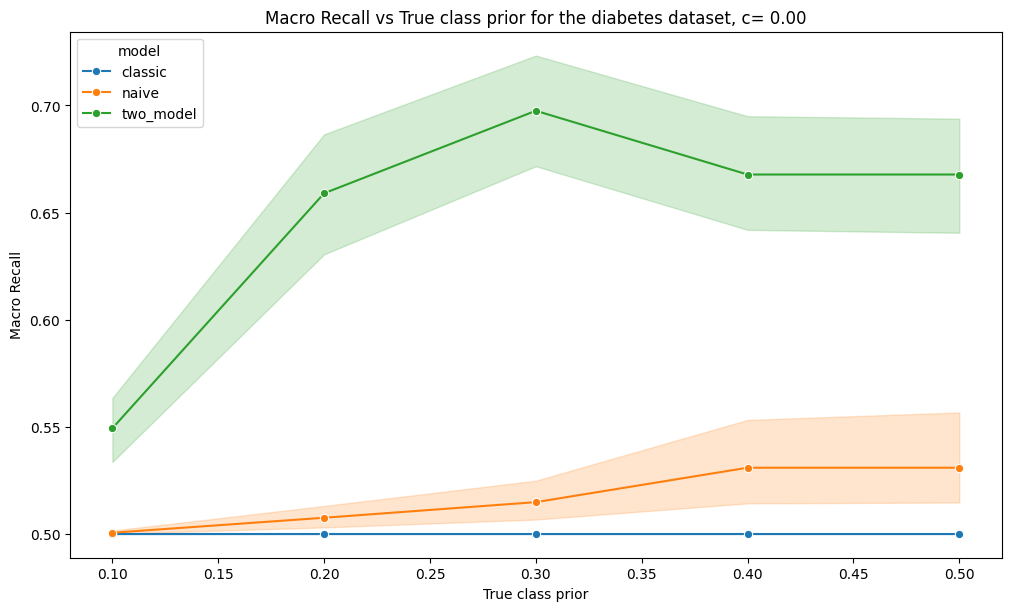

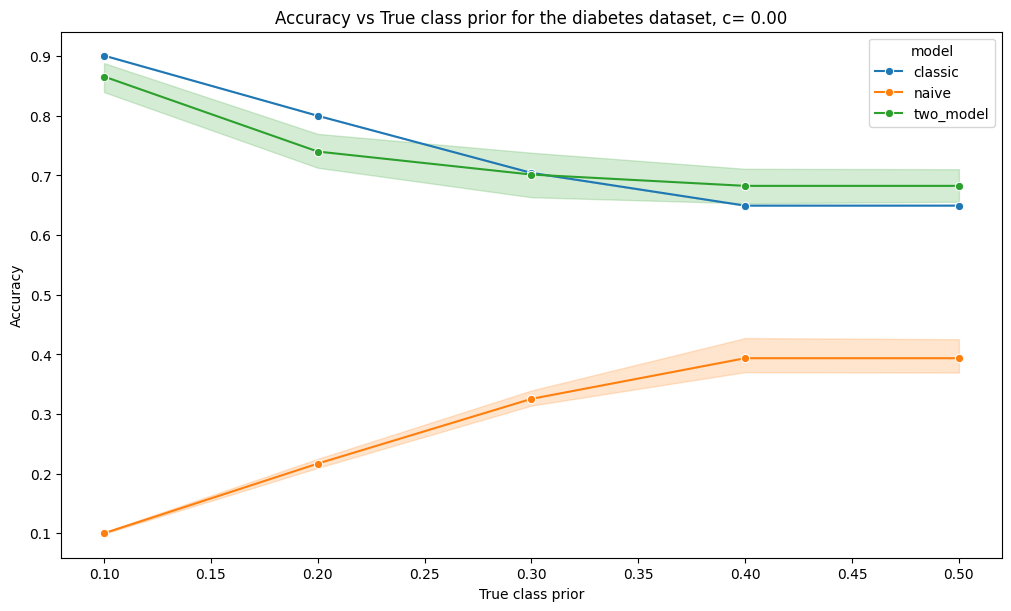

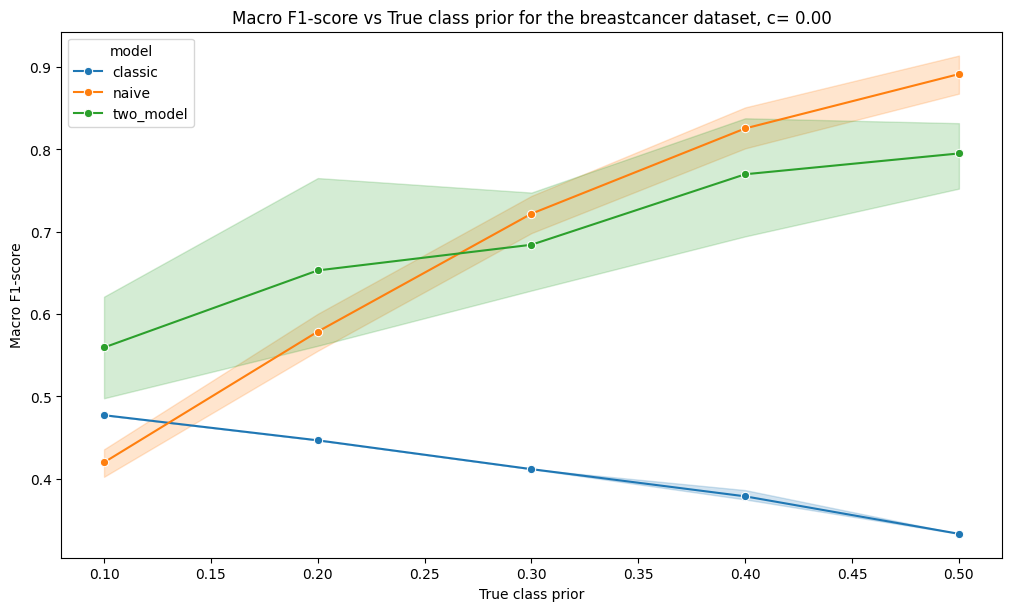

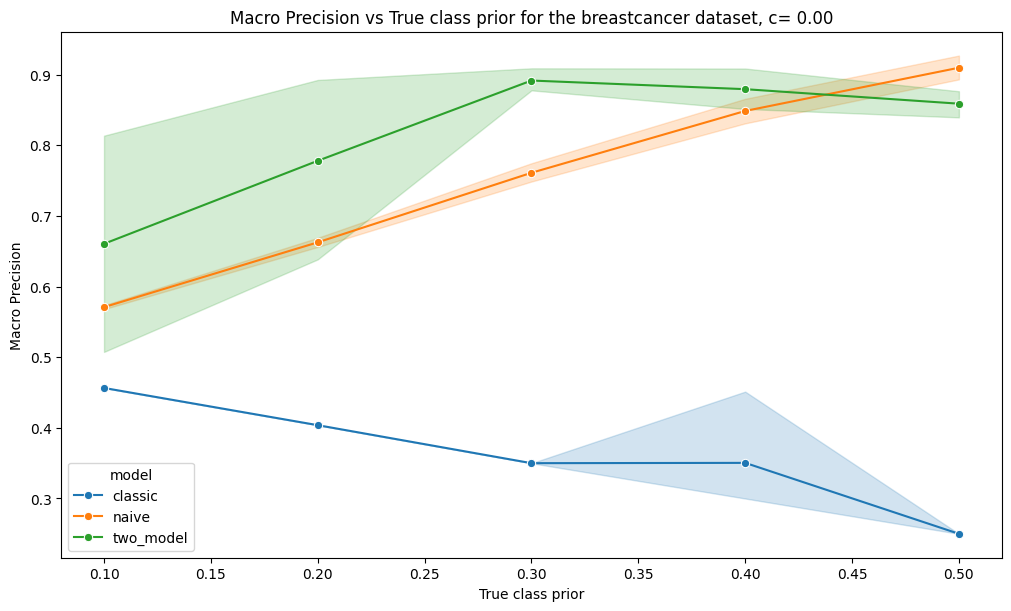

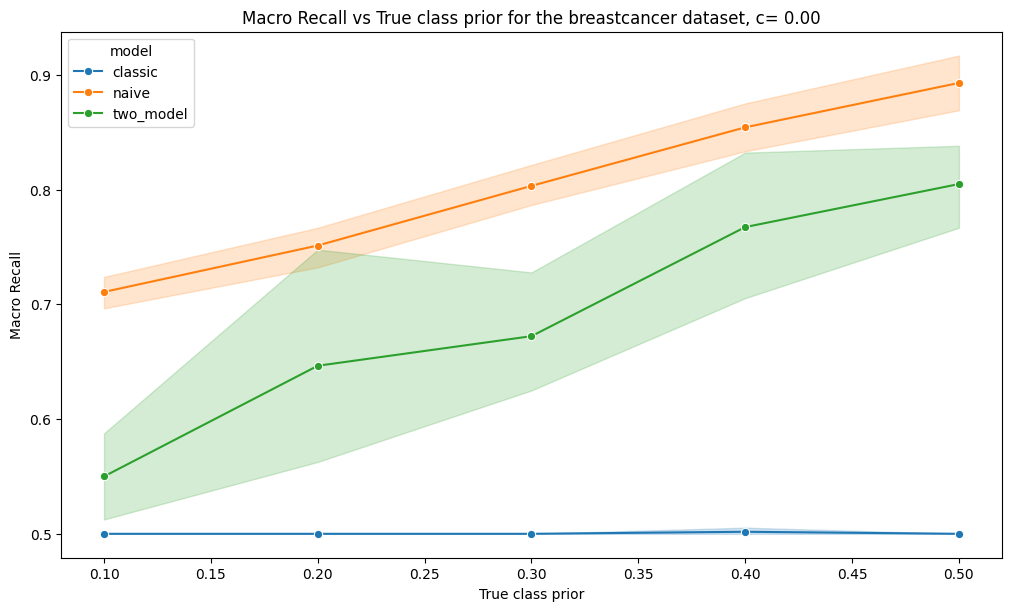

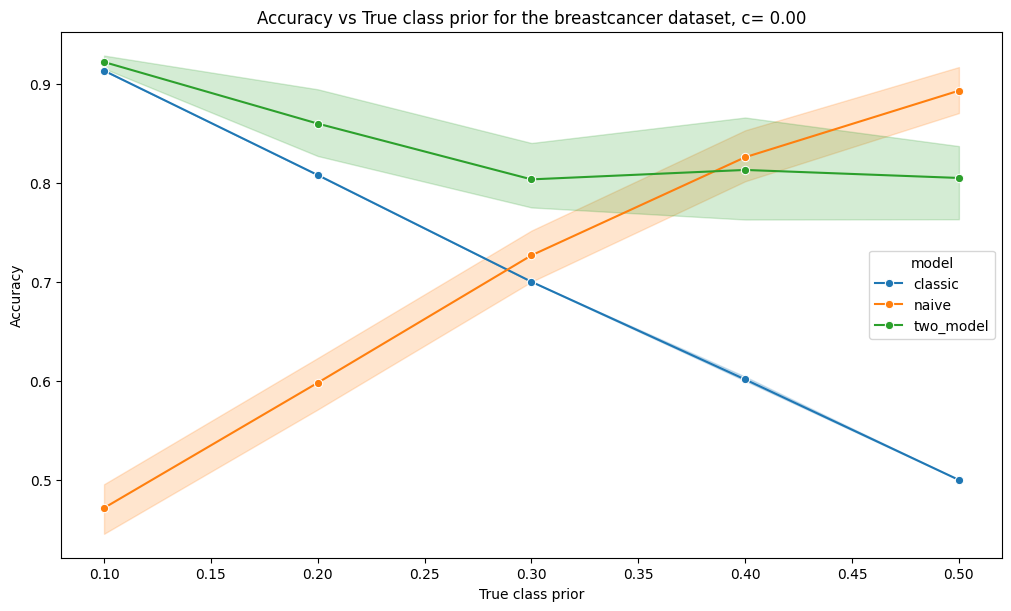

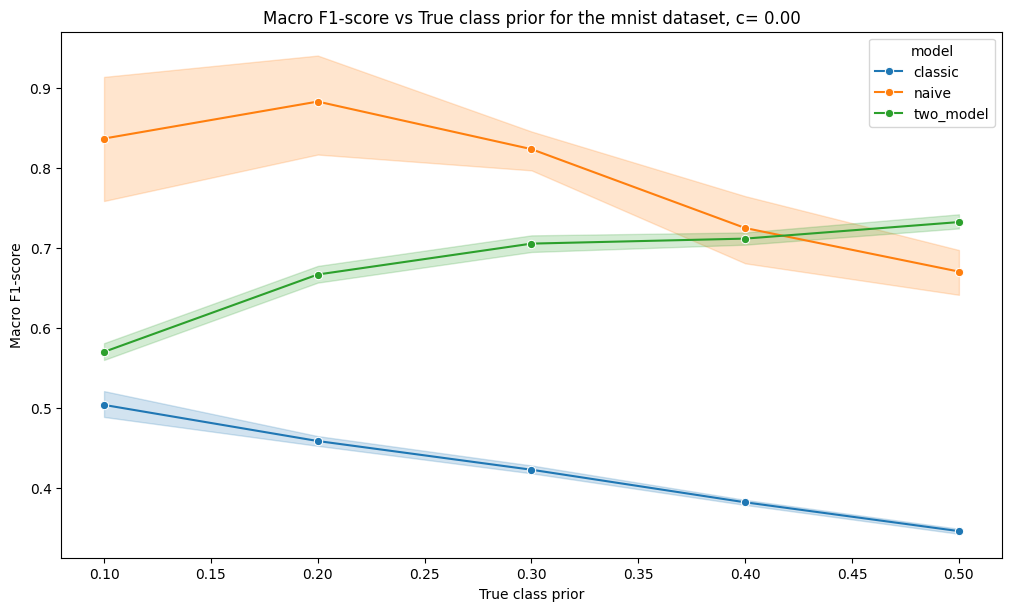

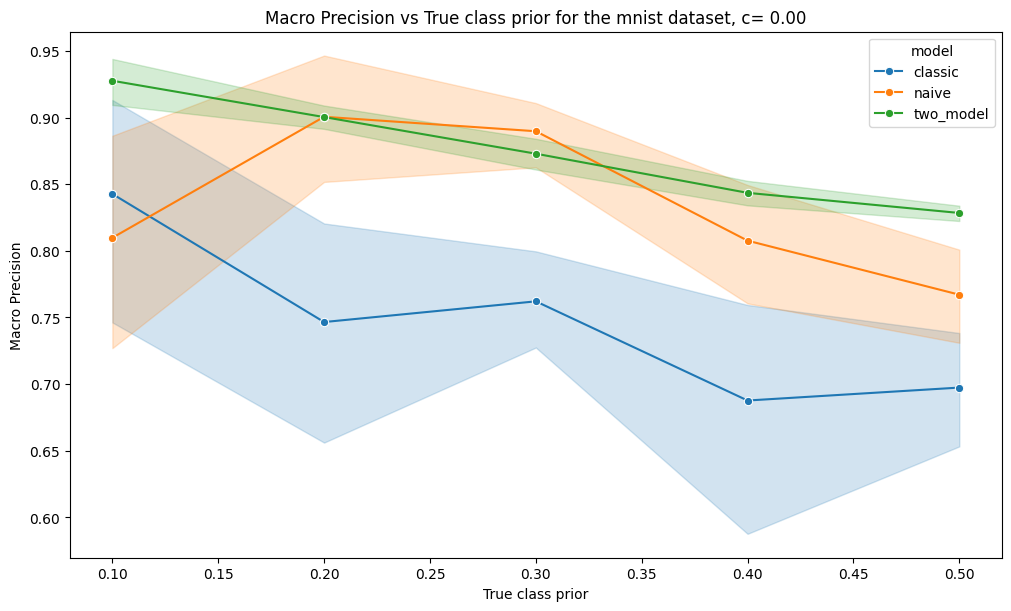

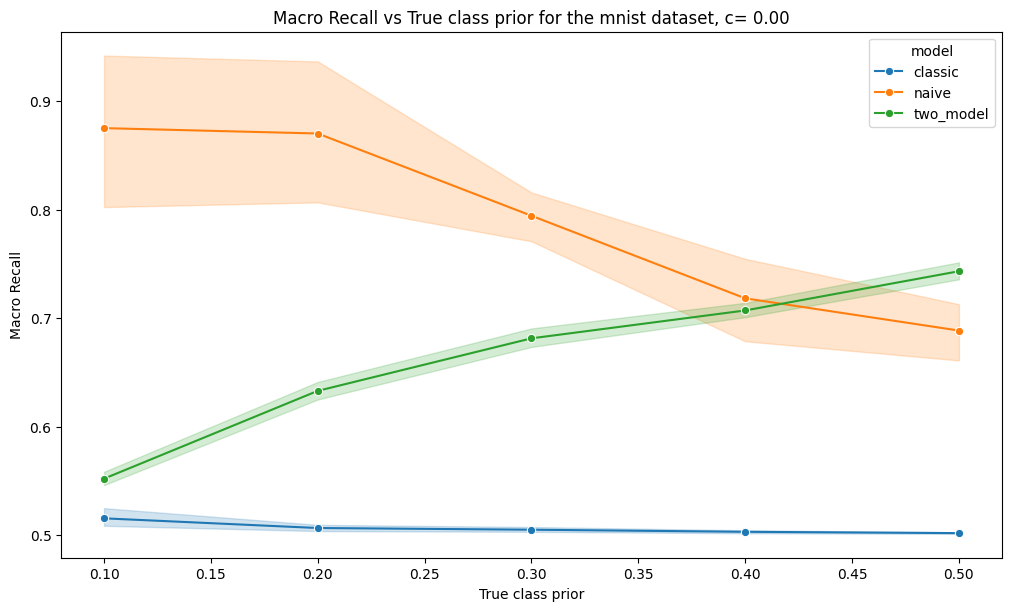

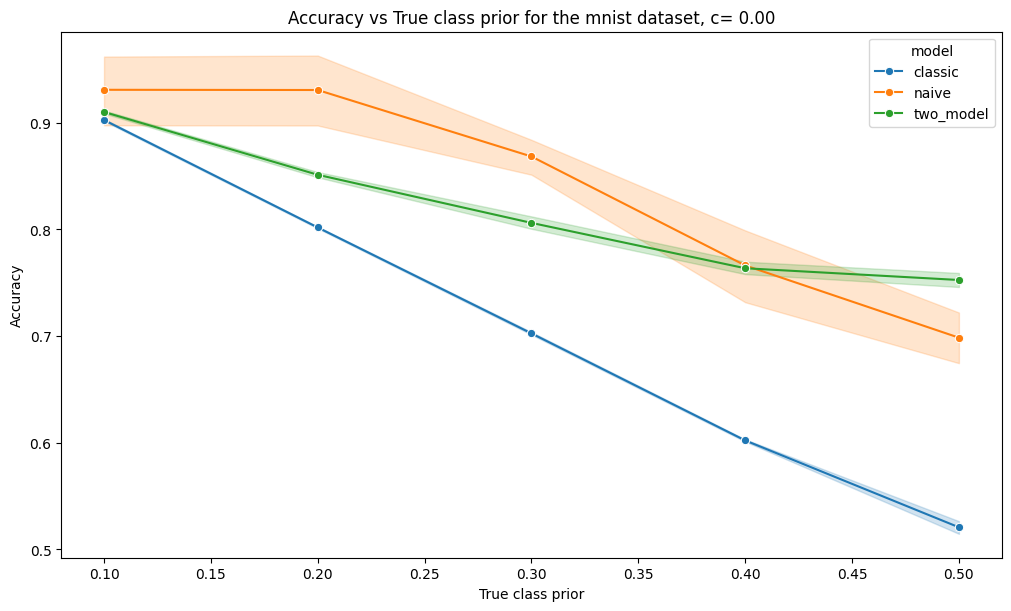

In [7]:


for dataset in df["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    values = df[df["dataset"]==dataset][EXPERIMENT].unique()
    def plot_metric(metric="f1",name="Macro F1-score"):
        
        plt.figure(figsize=(10, 6),layout='constrained')
        sns.lineplot(data=df[df["dataset"]==dataset], x=EXPERIMENT,y=metric,marker="o",hue="model")
        plt.title(f"{name} vs True class prior for the {dataset} dataset, c= {df.loc[df['dataset']==dataset,'calculated_c'].values[0]:.2f}")
        plt.ylabel(name)
        plt.xlabel("True class prior")
        plt.savefig(os.path.join(fig_folder,f"SAR_{name}_{dataset}.png"))
        plt.show()

    plot_metric(metric="f1",name="Macro F1-score")
    plot_metric(metric="precision",name="Macro Precision")
    plot_metric(metric="recall",name="Macro Recall")
    plot_metric(metric="accuracy",name="Accuracy")

